# Laboratorio integrador: analizador de tendencias en noticias argentinas

**Duración estimada:** 1 hora

## Desafío
Vas a construir un sistema en Python que extraiga noticias de la web y las procese con `spaCy` para identificar entidades, verbos frecuentes, palabras clave y visualizaciones básicas.

## Resultados esperados
Al finalizar este laboratorio, vas a poder:
- extraer texto desde una URL periodística;
- encapsular análisis lingüístico en una clase reutilizable;
- generar visualizaciones a partir del texto procesado;
- integrar varias piezas en un pipeline simple de análisis de noticias.

## Modalidad de trabajo: pair programming con IA
En esta cátedra, `pair programming con IA` significa que la unidad de trabajo está formada por vos y un asistente de IA.

La IA puede ayudarte a:
- proponer estrategias;
- explicarte errores o mensajes del entorno;
- sugerir casos de prueba;
- comparar enfoques posibles;
- auditar código que ya escribiste.

La IA no reemplaza tu pensamiento. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu criterio.

## Bitácora breve de interacción con IA
Completá al menos una entrada por cada parte del laboratorio.

**Plantilla sugerida**
- Objetivo de la consulta.
- Prompt o pedido que hiciste.
- Qué te devolvió la IA.
- Qué conservaste.
- Qué corregiste o descartaste.
- Qué aprendiste del intercambio.


In [5]:
# Instalamos las librerías necesarias en modo silencioso (-q)
#!pip install spacy trafilatura pandas matplotlib wordcloud plotly -q
#!python -m spacy download es_core_news_lg -q


In [6]:
# Importación de librerías
import spacy
import trafilatura
import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.graph_objects as go
from stopwords_es import stopwords_es
# Es recomendable pasarlas a un set para que la búsqueda sea mucho más rápida
set_stopwords = set(stopwords_es)

nlp = spacy.load("es_core_news_lg")
print("Modelo y librerías cargadas.")


Modelo y librerías cargadas.


## Parte 1: extracción de noticias (15 minutos)

**Objetivo:** construir una función que reciba una URL y devuelva un diccionario con el texto limpio de la noticia.

**Antes de escribir código, hace esta consulta a la IA:**
- Pedile dos estrategias posibles para descargar y extraer el contenido principal de una página.
- Elegí una y explicá por qué.

**Recordatorio:** si la IA te propone código, revisalo antes de incorporarlo.


### El asistente me sugirió estas alternativas para usar
1. Estrategia "Legos" (Requests + BeautifulSoup)
2. Estrategia "Automatizada" (Library Newspaper3k)

elegí la opción 2 porque es una librería especializada en noticias. No solo descarga el HTML, sino que usa algoritmos para identificar cuál es el título, cuál es el autor y cuál es el cuerpo principal, descartando automáticamente los menús laterales y comentarios.
Además es una librería que no usamos en las clases


In [7]:
import pandas as pd
from newspaper import Article, ArticleException
import requests
import time

def extraer_contenido(url):
    """
    Intenta descargar y parsear una URL. 
    Retorna un diccionario con los datos o None si falla.
    """
    try:
        # Verificación previa de estado (opcional pero recomendada)
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Lanza error si es 404, 500, etc.

        # 2. Procesamiento con Newspaper3k
        article = Article(url, language='es')
        article.download()
        article.parse()
        
        return {
            'url': url,
            'titulo': article.title,
            'texto': article.text,
            'fecha': article.publish_date
        }

    except requests.exceptions.HTTPError as e:
        print(f"Error HTTP en {url}: {e}")
    except requests.exceptions.ConnectionError:
        print(f"Error de conexión en {url}")
    except ArticleException:
        print(f"Newspaper3k no pudo parsear {url}")
    except Exception as e:
        print(f"Error inesperado en {url}: {e}")
    
    return None

def procesar_lista_urls(lista_urls):
    """
    Recorre el array de URLs y construye el DataFrame final.
    """
    resultados = []
    
    print(f"Iniciando descarga de {len(lista_urls)} artículos...\n")
    
    for i, url in enumerate(lista_urls):
        print(f"[{i+1}/{len(lista_urls)}] Procesando: {url}")
        
        datos = extraer_contenido(url)
        
        if datos:
            resultados.append(datos)
        
        # Un pequeño delay de cortesía para no saturar servidores
        time.sleep(1) 
    
    # Creamos el DataFrame con los resultados exitosos
    df_final = pd.DataFrame(resultados)
    print(f"\nProceso terminado. Artículos recuperados: {len(df_final)}")
    return df_final

# --- Ejemplo de uso ---
mis_urls = [
    "https://www.bbc.com/mundo/articles/czd7956pl63o",
    "https://www.lanacion.com.ar/videos/los-edificios-menos-conocidos-de-buenos-aires-que-sorprenden-por-su-historia-y-arquitectura-nid25042026/",
    "https://www.infobae.com/economia/2026/04/27/ranking-mundial-que-puesto-ocupa-la-argentina-en-el-sector-turistico-y-como-es-la-comparacion-con-otros-paises/"
]

df_articulos = procesar_lista_urls(mis_urls)

# Ahora podrías ver tus columnas
if not df_articulos.empty:
    print(df_articulos.head())

Iniciando descarga de 3 artículos...

[1/3] Procesando: https://www.bbc.com/mundo/articles/czd7956pl63o
[2/3] Procesando: https://www.lanacion.com.ar/videos/los-edificios-menos-conocidos-de-buenos-aires-que-sorprenden-por-su-historia-y-arquitectura-nid25042026/
[3/3] Procesando: https://www.infobae.com/economia/2026/04/27/ranking-mundial-que-puesto-ocupa-la-argentina-en-el-sector-turistico-y-como-es-la-comparacion-con-otros-paises/

Proceso terminado. Artículos recuperados: 3
                                                 url  \
0    https://www.bbc.com/mundo/articles/czd7956pl63o   
1  https://www.lanacion.com.ar/videos/los-edifici...   
2  https://www.infobae.com/economia/2026/04/27/ra...   

                                              titulo  \
0  Una "cortina de hierro digital": cómo el creci...   
1  Los edificios menos conocidos de Buenos Aires ...   
2  Ranking mundial: qué puesto ocupa la Argentina...   

                                               texto  \
0  Una "corti

## Parte 2: análisis de texto con spaCy (20 minutos)

**Objetivo:** encapsular el análisis en una clase `AnalizadorNoticia`.

**Consulta sugerida a la IA antes de completar los métodos:**
- Pedile un mapa de responsabilidades para la clase.
- Pedile criterios para distinguir personas, organizaciones y lugares a partir de `ent.label_`.
- Después compara esa propuesta con la documentación o con las salidas del modelo.


### Mapa de Responsabilidades: AnalizadorNoticia

*Gestión de Estado (Constructor):* Almacenar el texto original y, lo más importante, procesar el objeto doc de spaCy una sola vez para ahorrar recursos computacionales.

*Extracción Semántica (obtener_entidades):* Clasificar y agrupar el conocimiento (personas, empresas, lugares) para dar contexto al investigador.

*Análisis de Acción (obtener_verbos_principales):* Identificar las dinámicas del discurso (qué se está haciendo) mediante la lematización de verbos.

*Auditoría Estructural (obtener_estadisticas):* Cuantificar la complejidad y extensión del contenido.

*Contextualización de Datos (extraer_frases_con_entidad):* Permitir al investigador hacer "zoom" en menciones específicas dentro de su contexto original.

In [8]:
class AnalizadorNoticia:

    def __init__(self, texto, nlp_model):
        """
        Recibe el texto crudo y el modelo cargado (ej: spacy.load('es_core_news_lg')).
        Procesa el documento inmediatamente para que los demás métodos sean rápidos.
        """
        self.texto = texto
        self.doc = nlp_model(texto)

    def obtener_entidades(self):
        """Devuelve un diccionario con entidades agrupadas por tipo."""
        entidades = {
            'PERSONAS': [],
            'ORGANIZACIONES': [],
            'LUGARES': [],
            'OTROS': []
        }
        
        for ent in self.doc.ents:
            # Clasificación basada en las etiquetas de spaCy
            if ent.label_ == 'PER':
                entidades['PERSONAS'].append(ent.text)
            elif ent.label_ == 'ORG':
                entidades['ORGANIZACIONES'].append(ent.text)
            elif ent.label_ == 'LOC':
                entidades['LUGARES'].append(ent.text)
            else:
                entidades['OTROS'].append(ent.text)
        
        # Limpiamos duplicados convirtiendo a set y volviendo a lista
        for categoria in entidades:
            entidades[categoria] = list(set(entidades[categoria]))
            
        return entidades

    def obtener_verbos_principales(self, n=10):
        """Devuelve una lista de tuplas (verbo_lematizado, frecuencia)."""
        verbos = [token.lemma_.lower() for token in self.doc if token.pos_ == "VERB"]
        frecuencias = Counter(verbos)
        return frecuencias.most_common(n)

    def obtener_estadisticas(self):
        """Calcula estadísticas descriptivas básicas del texto."""
        palabras = [token.text for token in self.doc if not token.is_punct and not token.is_space]
        
        return {
            'total_tokens': len(self.doc),
            'total_palabras': len(palabras),
            'total_oraciones': len(list(self.doc.sents)),
            'palabras_unicas': len(set(p.lower() for p in palabras))
        }

    def extraer_frases_con_entidad(self, nombre_entidad):
        """Devuelve oraciones que contengan una entidad específica."""
        oraciones_encontradas = []
        for sent in self.doc.sents:
            # Buscamos si el nombre de la entidad está presente en la oración
            if nombre_entidad.lower() in sent.text.lower():
                oraciones_encontradas.append(sent.text.strip())
        return oraciones_encontradas
    
    def obtener_palabras_limpias(self):
        return [
            token.lemma_.lower() 
            for token in self.doc 
            if token.is_alpha          
            and not token.is_space     
            and token.lemma_.lower() not in set_stopwords
                ]

In [9]:
#Cargar el modelo de spaCy (hacerlo una sola vez fuera del bucle)
nlp = spacy.load("es_core_news_lg")

# 2. Función puente para aplicar la clase al DataFrame
def analizar_fila(texto):
    if not texto or len(str(texto)) < 10:
        return None
    # Instanciamos la clase para cada noticia
    return AnalizadorNoticia(texto, nlp)

# 3. Creamos una nueva columna que contenga los OBJETOS de la clase
# Esto nos permite tener todo el poder de tus métodos dentro del DF
df_articulos['analizador'] = df_articulos['texto'].apply(analizar_fila)

# 4. Ejemplo de cómo extraer información masiva para el Dashboard:
# Extraer los verbos principales de todas las noticias en una sola lista
todos_los_verbos = []
for obj in df_articulos['analizador']:
    if obj:
        # Pedimos los 5 verbos más frecuentes de cada artículo
        verbos = obj.obtener_verbos_principales(n=5)
        todos_los_verbos.extend([v[0] for v in verbos])

# Si querés ver las estadísticas generales de la primera noticia:
if not df_articulos.empty:
    primer_analisis = df_articulos['analizador'].iloc[0]
    if primer_analisis:
        print(f"Estadísticas: {primer_analisis.obtener_estadisticas()}")

Estadísticas: {'total_tokens': 2170, 'total_palabras': 1760, 'total_oraciones': 122, 'palabras_unicas': 730}


In [10]:
todos_los_verbos = []
for obj in df_articulos['analizador']:
    if obj:
        # Pedimos los 5 verbos más frecuentes de cada artículo
        verbos = obj.obtener_verbos_principales(n=5)
        # En lugar de guardar solo el nombre, multiplicamos el nombre por su frecuencia
        for nombre, frecuencia in verbos:
            todos_los_verbos.extend([nombre] * frecuencia) # Agrega el nombre 'frecuencia' veces
#        todos_los_verbos.extend([v[0] for v in verbos])
#print(verbos)  # Imprime los 5 verbos más frecuentes del último artículo procesado
#print(len(verbos))  # Imprime la cantidad total de verbos recopilados
#print("Verbos principales extraídos de todas las noticias:", set(todos_los_verbos))
#print(len(todos_los_verbos))  # Imprime la cantidad total de verbos recopilados


In [11]:
from collections import Counter
resumen_agenda = Counter(todos_los_verbos).most_common()
#print(resumen_agenda)
#print(len(resumen_agenda))  # Imprime la cantidad total de verbos recopilados

## Parte 3: visualización de resultados (20 minutos)

**Objetivo:** construir dos visualizaciones simples a partir del texto procesado.

**Consulta sugerida a la IA:**
- Pedile criterios para decidir qué tokens conviene excluir de una nube de palabras.
- Pedile una propuesta de estructura para un gráfico de barras horizontal.
- Después revisa si esas sugerencias se ajustan a tu caso.


In [12]:
print(df_articulos.columns)
#df_articulos.info()
df_articulos.head()
#print(df_articulos['url'].value_counts())
print (df_articulos.head(10))

Index(['url', 'titulo', 'texto', 'fecha', 'analizador'], dtype='str')
                                                 url  \
0    https://www.bbc.com/mundo/articles/czd7956pl63o   
1  https://www.lanacion.com.ar/videos/los-edifici...   
2  https://www.infobae.com/economia/2026/04/27/ra...   

                                              titulo  \
0  Una "cortina de hierro digital": cómo el creci...   
1  Los edificios menos conocidos de Buenos Aires ...   
2  Ranking mundial: qué puesto ocupa la Argentina...   

                                               texto  \
0  Una "cortina de hierro digital": cómo el creci...   
1  Con más de 16 años viviendo en la ciudad, Vane...   
2  El turismo ha crecido en Argentina, pero conti...   

                              fecha  \
0                              None   
1  2026-04-25 15:22:16.415000+00:00   
2               2026-04-27 00:00:00   

                                          analizador  
0  <__main__.AnalizadorNoticia object at 0x

In [13]:
palabras_relevantes = []

for obj in df_articulos['analizador']:
    if obj:
        # Usamos el nuevo método de la clase
        limpias = obj.obtener_palabras_limpias()
        palabras_relevantes.extend(limpias)

print(f"Total de palabras recolectadas: {len(palabras_relevantes)}")
print(f"Muestra de las primeras 10: {palabras_relevantes[:10]}")

Total de palabras recolectadas: 1867
Muestra de las primeras 10: ['cortina', 'hierro', 'digital', 'cómo', 'creciente', 'control', 'kremlin', 'internet', 'aumentar', 'descontento']


In [14]:
import plotly.express as px
import pandas as pd


def crear_nube_palabras(df):
    """Crea y muestra una nube de palabras a partir de un Doc de spaCy."""
    palabras_relevantes = []

    for obj in df['analizador']:
        if obj:
            limpias = obj.obtener_palabras_limpias()
            palabras_relevantes.extend(limpias)

    texto_limpio = ' '.join(palabras_relevantes)

    if texto_limpio:
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False,
        ).generate(texto_limpio)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.show()
    else:
        print("No hay suficientes palabras relevantes para generar la nube.")


def visualizar_entidades_mas_comunes(datos_entidades, n=10):
    """
    datos_entidades: Puede ser la lista total de entidades 
    o el resultado de un most_common().
    """
    # Si ya es una lista de tuplas (resultado de most_common), la usamos directo
    if isinstance(datos_entidades, list) and len(datos_entidades) > 0 and isinstance(datos_entidades[0], tuple):
        entidades_comunes = datos_entidades[:n]
    else:
        # Si es la lista plana, la contamos acá
        from collections import Counter
        entidades_comunes = Counter(datos_entidades).most_common(n)

    if not entidades_comunes:
        print("No se encontraron entidades para visualizar.")
        return None

    # Creamos el DataFrame
    df_plot = pd.DataFrame(entidades_comunes, columns=['Entidad', 'Frecuencia'])
    df_plot = df_plot.sort_values(by='Frecuencia', ascending=True)

    # Creamos la figura
    fig = px.bar(
        df_plot, 
        x='Frecuencia', 
        y='Entidad',
        orientation='h',
        title=f'Top {len(df_plot)} Entidades más mencionadas',
        text='Frecuencia',
        color='Frecuencia',
        color_continuous_scale='Viridis',
        template='plotly_white' # Estilo limpio para Colab
    )
    
    fig.update_traces(textposition='outside')
   
    fig.show()


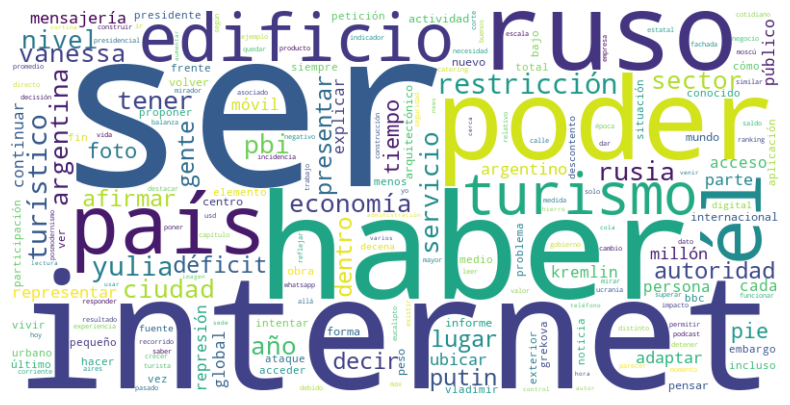

In [15]:
crear_nube_palabras(df_articulos)
#entidades_dict = AnalizadorNoticia.obtener_entidades(df_articulos)
#visualizar_entidades_mas_comunes(entidades_dict, n=10)

In [16]:
from collections import Counter

todas_las_entidades = []

for obj in df_articulos['analizador']:
    if obj:
        # Llamamos al método de tu clase
        dicc_entidades = obj.obtener_entidades()
       
        # Consolidamos personas, organizaciones y lugares en una sola bolsa
        for categoria in ['PERSONAS', 'ORGANIZACIONES', 'LUGARES']:
            todas_las_entidades.extend(dicc_entidades[categoria])

# Contamos cuáles son las más frecuentes en toda la muestra
entidades_comunes = Counter(todas_las_entidades).most_common(15)
print("Top Entidades:")
print(todas_las_entidades)
print(len(todas_las_entidades))

print("Top Entidades:")
for ent, freq in entidades_comunes:
    print(f"{ent}: {freq}")
visualizar_entidades_mas_comunes(todas_las_entidades, n=10)

Top Entidades:
['Han', 'Putin', 'Victoria Bonya', 'Instagram', 'Steve Rosenberg', 'Vladimir', 'Pierden', 'Novaya Gazeta', 'Peskov', 'Denis', 'Vladimir Putin', 'Yulia Grekova', 'Boris Nadezhdin', 'Después', 'María', 'Alexander', 'Andrei Kolesnikov', 'Yulia', 'Dmitry Peskov', 'Unión Soviética', 'BBC News Mundo', 'BBC News', 'BBC', 'Estado', 'Google', 'Rusia', 'Ucrania', 'Occidente', 'Penza', 'Moscú', 'Estado', 'Kremlin', 'Fuente de la imagen', 'Siberia', 'Alsina', 'Décadas', 'Mario Botta', 'Vanessa', 'Le Corbusier', 'Jorge Ferrari Hardoy', 'Vanessa Bell', 'Juan Kurchan', 'Banco Nazionale del Lavoro', 'UBA', 'Congreso', 'Mirador Massue', 'Ciudad', 'Los Eucaliptos', 'Palacio Costaguta', 'Alsina', 'Europa', 'Vanessa', 'Entre Ríos', 'Buenos Aires', 'acá', 'Fundar', 'EFE', 'Andorra', 'Croacia', 'Colombia', 'Georgia', 'Jordania', 'Canadá', 'Australia', 'Grecia', 'Italia', 'Mongolia', 'España', 'Macao', 'Chile', 'Uruguay', 'América del Sur', 'Islas Vírgenes', 'Filipinas', 'la Argentina', 'Portu

## Parte 4: integración en un pipeline (10 minutos)

**Objetivo:** integrar extracción, análisis y reporte agregado para varias noticias.

En esta parte conviene trabajar de menor a mayor:
1. probá con una sola URL;
2. verificá que el texto se extraiga;
3. recién después procesa una lista.


In [17]:
class AnalizadorTendencias:
    resultados = []

    def __init__(self, lista_urls):
        self.urls = lista_urls
        self.noticias_data = []
        self.analizadores = []
        self.nlp = spacy.load("es_core_news_lg")

    def procesar_todas(self):
        """Orquesta la extracción y el análisis de todas las URLs."""
        print(f"Iniciando procesamiento de {len(self.urls)} URLs...")

        for i, url in enumerate(self.urls):
            print(f"[{i+1}/{len(self.urls)}] Procesando: {url}")
            
            datos = extraer_contenido(url) # Tu función de scraping
            
            if datos:
                self.resultados.append(datos)
                # guardamos el analizador individual para cada noticia
                nuevo_analisis = AnalizadorNoticia(datos['texto'], self.nlp)
                self.analizadores.append(nuevo_analisis)

            # El delay va dentro del for para ser amigable con el servidor
            time.sleep(1) 
    
        print("Procesamiento completado.")
        df_final = pd.DataFrame(self.resultados)
        print(f"\nProceso terminado. Artículos recuperados: {len(df_final)}")
        return df_final
    
    def generar_reporte_agregado(self, n=15):
        """Genera un reporte consolidado de todas las noticias procesadas."""
        if not self.analizadores:
            print("No hay noticias procesadas para generar un reporte.")
            return

        # Bolsas globales para acumular
        lista_entidades_plana = []
        todos_los_verbos = []

        for ana in self.analizadores:
            # Extraer y aplanar entidades
            ents = ana.obtener_entidades()
            # Combinamos las listas de cada categoría en una sola lista de strings
            menciones_articulo = ents['PERSONAS'] + ents['ORGANIZACIONES'] + ents['LUGARES']
            lista_entidades_plana.extend(menciones_articulo)

            # Extraer verbos (usando la lógica de frecuencia que vimos antes)
            verbos_data = ana.obtener_verbos_principales(n=10)
            for nombre_verbo, freq in verbos_data:
                todos_los_verbos.extend([nombre_verbo] * freq)

        # --- Visualización ---
        print(f"\n--- REPORTE AGREGADO DE {len(self.analizadores)} NOTICIAS ---")
        
        print("\n--- ENTIDADES MÁS COMUNES ---")
        # Pasamos la lista PLANA
        visualizar_entidades_mas_comunes(lista_entidades_plana, n=n)

        print("\n--- VERBOS MÁS COMUNES ---")
        frecuencias_verbos = Counter(todos_los_verbos)
        print(frecuencias_verbos.most_common(n))


In [18]:
mi_analizador = AnalizadorTendencias(mis_urls)
df_articulos = mi_analizador.procesar_todas()
mi_analizador.generar_reporte_agregado()


Iniciando procesamiento de 3 URLs...
[1/3] Procesando: https://www.bbc.com/mundo/articles/czd7956pl63o
[2/3] Procesando: https://www.lanacion.com.ar/videos/los-edificios-menos-conocidos-de-buenos-aires-que-sorprenden-por-su-historia-y-arquitectura-nid25042026/
[3/3] Procesando: https://www.infobae.com/economia/2026/04/27/ranking-mundial-que-puesto-ocupa-la-argentina-en-el-sector-turistico-y-como-es-la-comparacion-con-otros-paises/
Procesamiento completado.

Proceso terminado. Artículos recuperados: 3

--- REPORTE AGREGADO DE 3 NOTICIAS ---

--- ENTIDADES MÁS COMUNES ---



--- VERBOS MÁS COMUNES ---
[('tener', 8), ('afirmar', 7), ('decir', 7), ('presentar', 7), ('ubicar', 6), ('intentar', 4), ('acceder', 4), ('volver', 4), ('representar', 4), ('saber', 3), ('responder', 3), ('continuar', 3), ('mirar', 3), ('reflejar', 3), ('superar', 3)]


## Entregables, criterios de evaluación y cierre

### Entregables sugeridos
- Las funciones y clases completadas.
- Al menos una prueba con una noticia real.
- Una bitácora breve de interacción con IA.
- Una justificación corta sobre una decisión que tomaste a partir de una sugerencia de la IA y otra que descartaste.

### Criterios de evaluación
- **Funcionamiento técnico:** que el pipeline complete tareas básicas de extracción, análisis y visualización.
- **Juicio crítico:** que puedas explicar por qué elegiste una estrategia y no otra.
- **Uso de IA con criterio:** que la IA aparezca como apoyo de exploración, no como reemplazo del razonamiento.
- **Proceso documentado:** que la bitácora muestre qué tomaste, qué corregiste y qué descartaste.
- **Claridad del código:** que las funciones y clases sean legibles y consistentes.

### Checklist antes de entregar
- Probaste cada parte por separado antes de integrar todo?
- Podés explicar qué hace cada función principal?
- Tu bitácora muestra intervención humana real sobre los outputs de IA?
- Hay al menos un ejemplo donde corregiste o descartaste una sugerencia de la IA?

Si respondiste que sí a estas preguntas, tu laboratorio ya está alineado con la propuesta pedagógica de la cátedra.
